<a href="https://colab.research.google.com/github/koigs/centrality/blob/main/Centralidade_IC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random as rd

%matplotlib inline

# Teoria de Grafos

Teoria de Grafos é uma área interdisciplinar de estudo que abrange matemática, ciência de dados e ciência da computação cujo papel é analisar as relações entre objetos, usualmente trabalhando com os termos “vértice” (ou “nó”) para os objetos e “arestas” para suas relações dentro de determinado conjunto. Grafos podem apresentar diferentes representações, sendo sua notação matemática usual $G =(V,E)$, onde $G$ representa o grafo, $V$ seus vértices e $E$ suas arestas (oriundo do termo em inglês **edges**).

A importância e versatilidade dos grafos fazem-se visíveis ao analisarmos a evolução do tratamento de dados e o abundante volume de informação com que a humanidade passou a conviver nos últimos séculos, abrangendo todas as áreas de estudo, a exemplo da  microbiologia, com a análise de colônias de bactérias com corte normalizado em grafos, por Costa (2013).

> [Costa 2013] COSTA, A. L. da; (2013). “Corte normalizado em grafos: um algoritmo aglomerativo para segmentação de imagens de colônias de bactérias”  Dissertação (mestrado) - Universidade Estadual de Campinas, Limeira, SP. Disponível em: <https://doi.org/10.47749/T/UNICAMP.2013.909115 >.






## Definições básicas e representação

Um grafo é um par $G=(V,E)$, onde $V$ é um conjunto finito e $E$ é um conjunto de pares não-ordenados de $V$.

Dizemos que vértices $u$ e $v$ são *adjacentes* se $\{u,v\} \in E$ e dizemos que $u$ e $v$ são *vizinhos* um do outro.

Exemplo: $G=(V,E)$ com $V = \{1,2,3,4,5,6,7\}$ e $E = \{\{1,2\}, \{1,3\},\{1,4\},\{2,5\},\{3,4\},\{4,5\},\{4,7\},\{6,7\},\{5,6\},\{2,4\},\{4,6\} \}$.

É comum denotar por $n$ o número de vértices de $G$ e por $m$ o número de arestas de $G$. No exemplo, $n=7$ e $m=11$.

Abaixo, implementamos uma representação para o grafo $G$ do exemplo utilizando listas.

In [ ]:
V = [1,2,3,4,5,6,7]
E = [[1,2],[1,3],[1,4],[2,5],[3,4],[4,5],[4,7],[6,7],[5,6],[2,4],[4,6]]
n = len(V)
m = len(E)
print("n =",n,"m =",m)
print("V =",V)
print("E =",E)

n = 7 m = 11
V = [1, 2, 3, 4, 5, 6, 7]
E = [[1, 2], [1, 3], [1, 4], [2, 5], [3, 4], [4, 5], [4, 7], [6, 7], [5, 6], [2, 4], [4, 6]]


Grafos são comumente representados graficamente: adicionamos um nó por vértice e ligamos vértices adjacentes. A seguir, utilizamos a biblioteca `networkx` para a geração da representação gráfica.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def representacao(V,E,size=100,labels=True,layout="shell"):
    G = nx.DiGraph()
    G.add_edges_from(E)
    pos = nx.shell_layout(G)
    if layout=="spring":
        pos=nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size = size)
    if labels:
        nx.draw_networkx_labels(G, pos)
    nx.draw_networkx_edges(G, pos, edge_color='grey', arrows=False)
    plt.show()

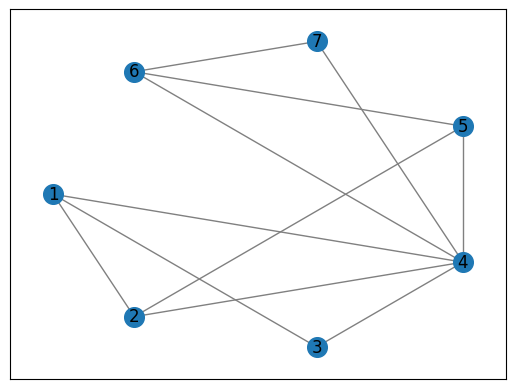

In [ ]:
representacao(V,E, size=200)

A implementação acima para grafo é uma implementação direta da definição matemática. No entanto, ela não é uma boa estrutura de dados pois não é eficiente para encontrar os vizinhos de um vértice, o que é uma operação utilizada com frequência.

Utilizamos listas de adjacência: cada vértice tem uma lista com seus vizinhos.

O número de arestas é a soma dos comprimentos dessas listas dividido por $2$.

In [ ]:
V = [1,2,3,4,5,6,7]
E = {1:[2,3,4],
     2:[1,5,4],
     3:[1,4],
     4:[1,2,3,5,6,7],
     5:[2,4,6],
     6:[4,5,7],
     7:[4,6]}
n = len(V)

m = 0
for v in E:
    m += len(E[v])
m = m//2

print("n =",n,"m =",m)
print("V =",V)
print("E =",E)

n = 7 m = 11
V = [1, 2, 3, 4, 5, 6, 7]
E = {1: [2, 3, 4], 2: [1, 5, 4], 3: [1, 4], 4: [1, 2, 3, 5, 6, 7], 5: [2, 4, 6], 6: [4, 5, 7], 7: [4, 6]}


Veja abaixo a simplicidade para percorrer os vizinhos de um vértice com esta implementação:

In [ ]:
#percorrendo vizinhos do vértice v
v = 4
print("Vizinhos de", v)
for u in E[v]:
    print(u)

Vizinhos de 4
1
2
3
5
6
7


Pode ser útil obter o conjunto de arestas do grafo a partir das listas de adjacência. Implementamos a seguinte função:

In [ ]:
def E_aslist(V,E):
    E_conj = []
    for v in V:
        for u in E[v]:
            if [u,v] not in E_conj and [v,u] not in E_conj:
                E_conj.append([u,v])
    return E_conj

In [ ]:
E_aslist(V,E)

[[2, 1],
 [3, 1],
 [4, 1],
 [5, 2],
 [4, 2],
 [4, 3],
 [5, 4],
 [6, 4],
 [7, 4],
 [6, 5],
 [7, 6]]

# Grafos aleatórios

Um grafo aleatório trata-se de um grafo cuja uma ou mais propriedades como nós, arestas e suas relações são determinadas através de alguma forma aleatória. Esse ramo de estudo que associa teoria probabilística à teoria dos grafos tem início demarcado por Erdős e Rényi (1959, 1960) com o modelo binomial ou $G=(n,p)$  que desenvolveram para geração de grafos aleatórios, onde $G$ representa o grafo, $n$ o número de nós e $p$ a probabilidade da conexão para cada nó.

## Grafos de Erdős–Rényi
Dois dos modelos mais clássicos de grafos aleatórios são conhecidos como grafos de Erdős–Rényi: $G(n,p)$ e o $G(n,m)$.

Tanto no $G(n,p)$ quanto no $G(n,m)$, o conjunto de vértices tem tamanho $n$.
A construção de um grafo por meio do modelo $G(n,p)$ ocorre pela inclusão de cada possível aresta com probabilidade $p$  (e não inclusão com probabilidade $q = 1- p$). de um vértice não possuir uma aresta conectada à outro. Essa inclusão é independente das outras arestas. Essa definição propõe que a probabilidade de um grafo específico de $m$ arestas ocorrer é dada por: $p^m(1-p)^{\binom{n}{2}-m}$.

No $G(n,m)$ é sorteado um conjunto de arestas de tamanho $m$ uniformemente.

Aqui mostramos um código para gerar o $G(n,p)$.

In [ ]:
import random as rd
def ErdosRenyi(n,p):
    V = list(range(n))
    E = {}
    for v in range(n):
        E[v] = []
    for v in range(n):
        for u in range(v+1,n):
            x = rd.random()
            if x<p:
                E[v].append(u)
                E[u].append(v)
    return V,E

Veja a evolução deste grafo com valores crescente de $p$ (vértices sem arestas não são mostrados):

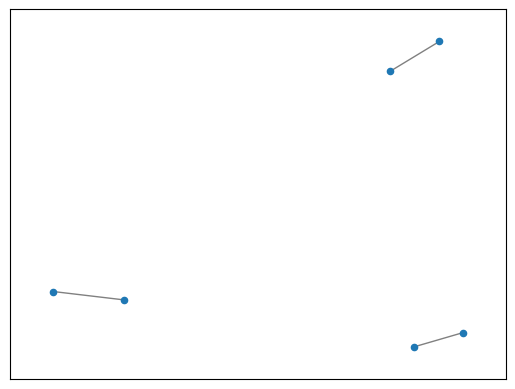

In [ ]:
V,E = ErdosRenyi(100,0.001)
E_list = E_aslist(V,E)
representacao(V,E_list,size=20,labels=False,layout="spring")

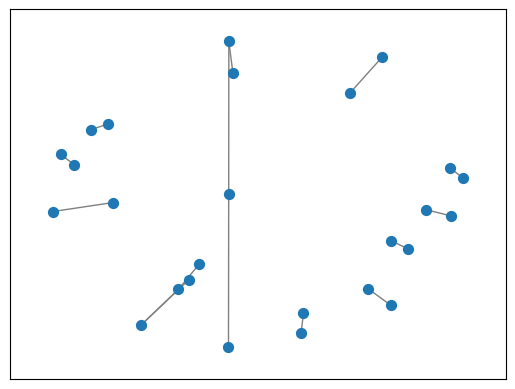

In [ ]:
V,E = ErdosRenyi(100,0.005)
E_list = E_aslist(V,E)
representacao(V,E_list,size=50,labels=False,layout="spring")

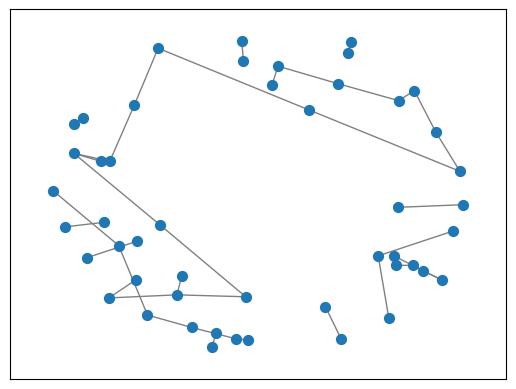

In [ ]:
V,E = ErdosRenyi(100,0.01)
E_list = E_aslist(V,E)
representacao(V,E_list,size=50,labels=False,layout="spring")

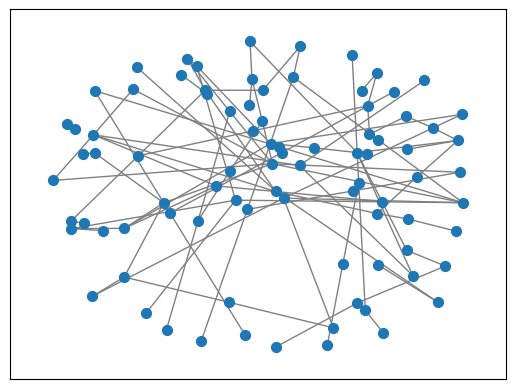

In [ ]:
V,E = ErdosRenyi(100,0.02)
E_list = E_aslist(V,E)
representacao(V,E_list,size=50,labels=False,layout="spring")

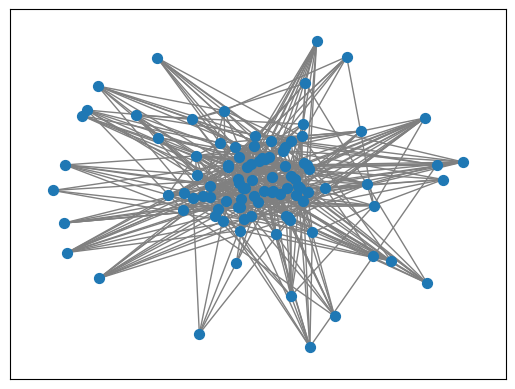

In [ ]:
V,E = ErdosRenyi(100,0.1)
E_list = E_aslist(V,E)
representacao(V,E_list,size=50,labels=False,layout="spring")

Diversos modelos de grafos aleatórios foram propostos. De fato, modelos diferentes tendem a gerar grafos com propriedades diferentes. Por exemplo, nos grafos de Erdős–Rényi, todos vértices têm a mesma chance de estarem de serem adjacentes. Mas em diversas redes no mundo real, isso não é uma característica realista, pois fatores locais afetam as adjacências.

## Grafos aleatórios geométricos
No grafo aleatório geométrico, os vértices são distribuídos aleatoriamente no quadrado unitário e vértices são adjacentes se sua distância é menor do que um raio dado.

In [ ]:
import random as rd
def Geom(n,r):
    V = list(range(n))
    E = {}
    x = {}
    y = {}
    for v in range(n):
        E[v] = []
        x[v] = 0
        y[v] = 0
    for v in range(n):
        x[v] = rd.random()
        y[v] = rd.random()
    for v in range(n):
        for u in range(v+1,n):
            dist2 = (x[v]-x[u])**2 + (y[v]-y[u])**2
            if dist2 < r*r:
                E[v].append(u)
                E[u].append(v)
    return V, E, x, y

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def rep_geom(v,E,x,y):
    for v in V:
        for u in E[v]:
            plt.plot([x[v],x[u]],[y[v],y[u]],"gray", linewidth=0.5)
    for v in V:
        plt.plot(x[v],y[v],".b")

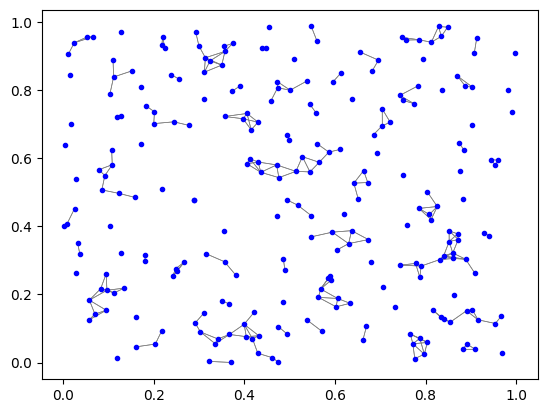

In [ ]:
V, E, x, y = Geom(250,0.05)
rep_geom(v,E,x,y)

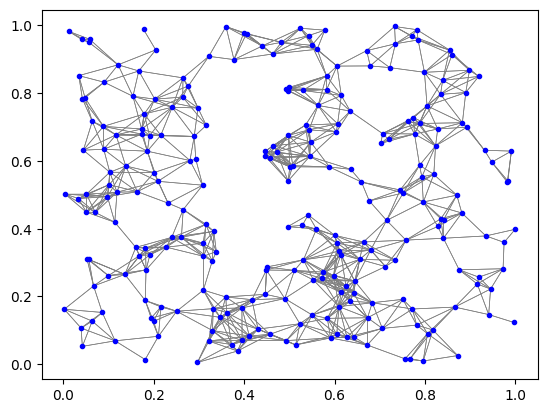

In [ ]:
V, E, x, y = Geom(250,0.1)
rep_geom(v,E,x,y)

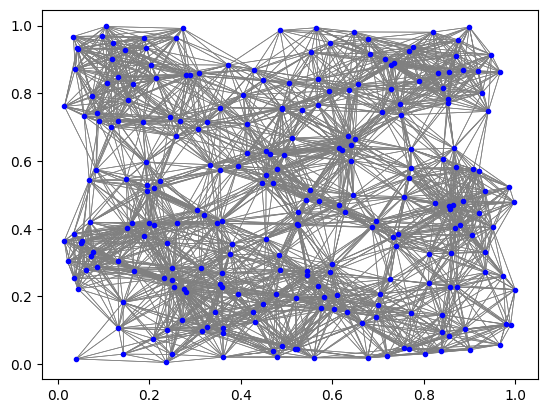

In [ ]:
V, E, x, y = Geom(250,0.2)
rep_geom(v,E,x,y)

## Modelo de Watts–Strogatz
O modelo de Watts–Strogatz[1998] procura gerar grafos com a propriedade de mundo pequeno.

O modelo de Watts-Strogatz  trabalha com a reconexão dos vértices de um grafo base $k$-regular. Os parâmetros do modelo são $n$ (número de vértices), $k$ (grau inicial) e $\beta$ (probabilidade de reconexão). O número $k$ deve ser par e menor do que $n$ e, tipicamente, maior do que $\log n$.

O primeiro passo é gerar um grafo $k$-regular que tem como vértices os números de $0$ a $n-1$. Cada vértice é ligado aos $k/2$ anteriores e $k/2$ posteriores.

Veja um exemplo:

In [ ]:
def Ring(n,k):
    V = list(range(n))
    E = {}
    for v in range(n):
        E[v] = []
    for v in range(n):
        for u in range(v+1,n):
            dif = u-v
            d = n-1-k/2
            r = dif % d
            if 0< r <= k/2:
                E[v].append(u)
                E[u].append(v)
    return V,E

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import math
import numpy as np

def rep_WS(V,E):
    n = len(V)
    angulo = 2*math.pi/n
    angulos = np.array(np.arange(0,2*math.pi, angulo))
    x = list(np.cos(angulos))
    y = list(np.sin(angulos))
    for v in V:
        for u in E[v]:
            plt.plot([x[v],x[u]],[y[v],y[u]],"gray",linewidth=0.5)
    plt.plot(x,y,".")
    plt.axis("equal")

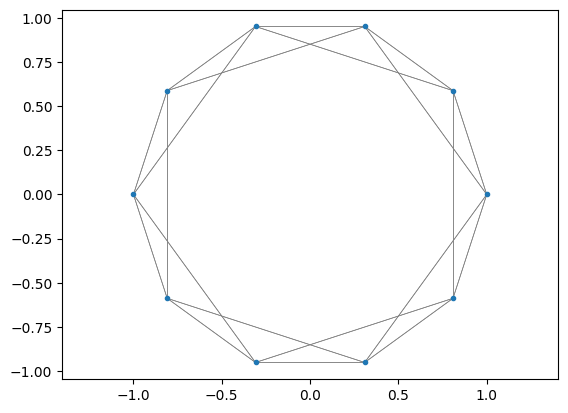

In [ ]:
n = 10
k = 4
V,E = Ring(n,k)
rep_WS(V,E)

Em seguida, percorremos os vértices em ordem. E para cada vértice $v$ e aresta gerada $uv$, um novo $u$ é escolhido com probabilidade $\beta$. Ou seja, cada aresta é re-roteada com probabilidade $\beta$.

In [ ]:
import random as rd
def WS(n, k, beta):
    V,E = Ring(n,k)
    for v in V:
        for u in E[v]:
            if u>v:
                x = rd.random()
                if x<beta:
                    E[v].remove(u)
                    E[u].remove(v)
                    w = rd.randint(0,n-1)
                    while w==v or w in E[v]:
                        w = rd.randint(0,n-1)
                    E[v].append(w)
                    E[w].append(v)
    return V,E

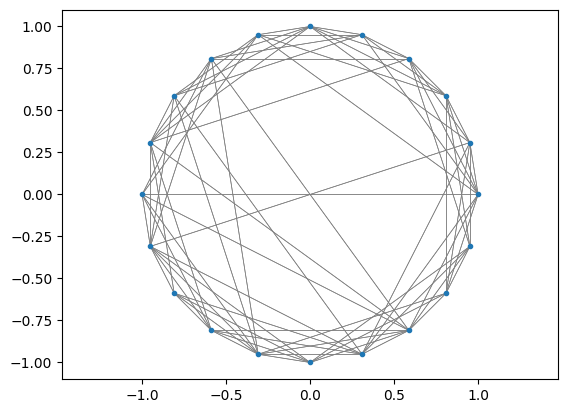

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.2)
rep_WS(V,E)

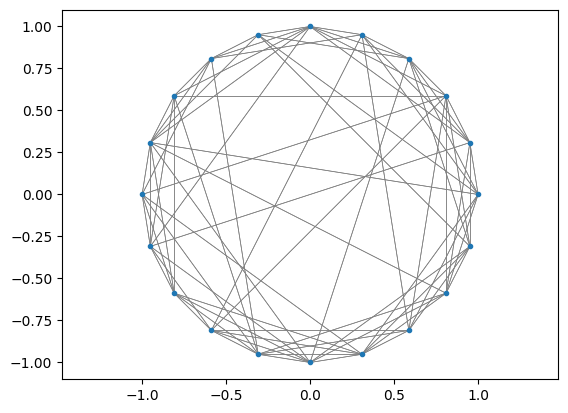

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.3)
rep_WS(V,E)

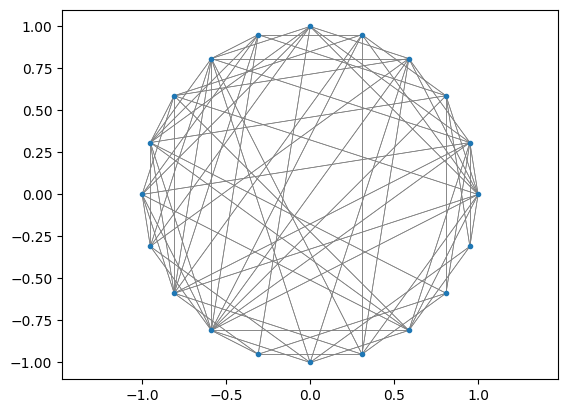

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.8)
rep_WS(V,E)

#Centralidade

Dentro do estudo de grafos, podemos destacar para este trabalho o conceito de Centralidade, cujo papel impacta o estudo da interconectividade dos nós dentro de determinado grafo. No interior de uma rede de informações, isso indica de diferentes formas qual seria o nó de maior importância dentro de um conjunto. O estudo de medidas de centralidade advém bastante da busca de melhor compreender o que um conjunto de dados pode significar considerando diferentes contextos, tal como entender quão influente pode ser uma pessoa dentro de uma rede de funcionários, compreender qual poderia ser um gene de maior relevância ou uma proteína essencial para um estudo dentro de microbiologia, saber qual seria o melhor caminho até uma cidade através da intuição de quais são os pontos de cruzamento mais relevantes, entre outras diversas aplicações.

Dado que cada medida traz consigo um caráter específico, a implementação de algoritmos de ordenação definidos por certa medida deve ser caracterizado por sua intenção. Para tanto, é preciso entender o papel e o funcionamento de cada tipo de medida de centralidade.

Medidas de Centralidade avaliam o papel que um nó desempenha na estrutura e dinâmica do grafo. Existem várias medidas de centralidade, cada uma destacando diferentes aspectos da importância de um nó. Trabalharemos com  as seguintes:
* Centralidade de Grau (degree centrality)
* Centralidade por proximidade (closeness centrality)
* Centralidade harmônica (harmonic centrality)
* Centralidade Page Rank



## Centralidade de grau
Medida de centralidade baseada no grau de cada vértice, ou quantos vértices vizinhos um vértice possui. Assume valores naturais ao tratar de grafos sem pesos, dado que o grau de um nó é definido pelo número de arestas conectados à si. Os vértices com maiores graus serão os mais centrais.

Uma vantagem prevista pela centralidade por grau é sua simplicidade computacional em relação a outras medidas de centralidade, o que a torna extremamente rápida comparativamente.
A análise por meio da centralidade por grau é por vezes criticada devido à sua consideração simplista de tratar apenas das conexões imediatas de um vértice. Vértices com alta centralidade por grau podem estar desconexos de uma rede apesar de muito conectados em seu próprio aglomerado, podendo levar a uma interpretação errônea em primeira análise quando se tratando de um nó considerado mais importante por centralidade de grau.


A centralidade de $v$ por grau no grafo $G$ é $d_G(v) = $ número de vizinhos de $v$ em $G$.

In [ ]:
def degree_centrality(V,E):
    deg = {}
    for v in V:
        deg[v] = len(E[v])
    return deg

In [ ]:
V = [1,2,3,4,5,6,7]
E = {1:[2,3,4],
     2:[1,5,4],
     3:[1,4],
     4:[1,2,3,5,6,7],
     5:[2,4,6],
     6:[4,5,7],
     7:[4,6]}
deg = degree_centrality(V,E)
deg

{1: 3, 2: 3, 3: 2, 4: 6, 5: 3, 6: 3, 7: 2}

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def representacao_cor(V,E,val_map,size=120,labels=True):
    G = nx.Graph()

    G.add_edges_from(E)
    pos = nx.spring_layout(G)

    values = [val_map.get(node, 0.25) for node in G.nodes()]
    if labels:
        nx.draw_networkx_labels(G, pos)

    nx.draw(G, pos,cmap=plt.get_cmap('viridis'), width=0.5,node_color=values,node_size=size, edge_color="gray", with_labels=labels, font_color='white')
    plt.show()

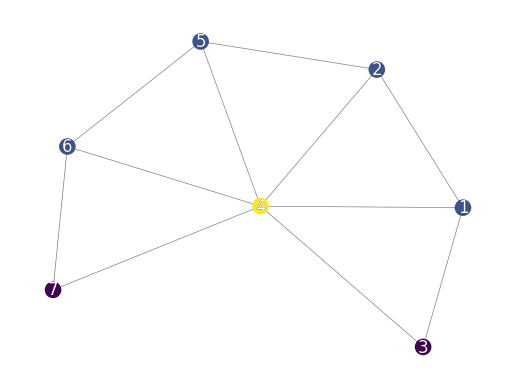

In [ ]:
E_list = E_aslist(V,E)
representacao_cor(V,E_list,deg)

### Centralidade de grau em grafos Erdős-Renyi

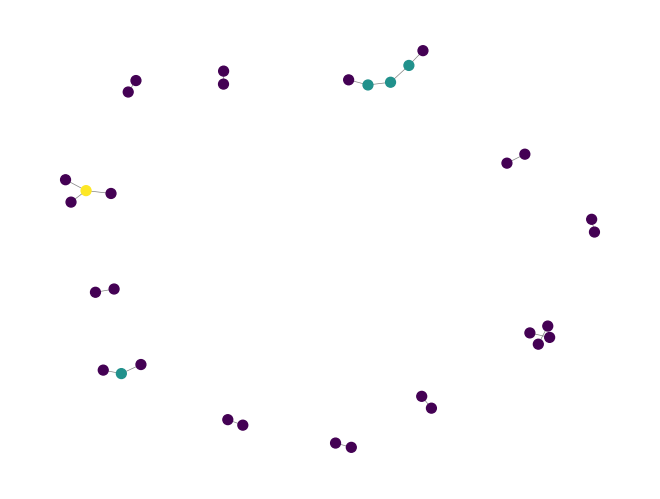

In [ ]:
n = 100
p = 0.005
(V,E) = ErdosRenyi(n,p)
deg = degree_centrality(V,E)
representacao_cor(V,E_aslist(V,E),deg,size = 50,labels=False)

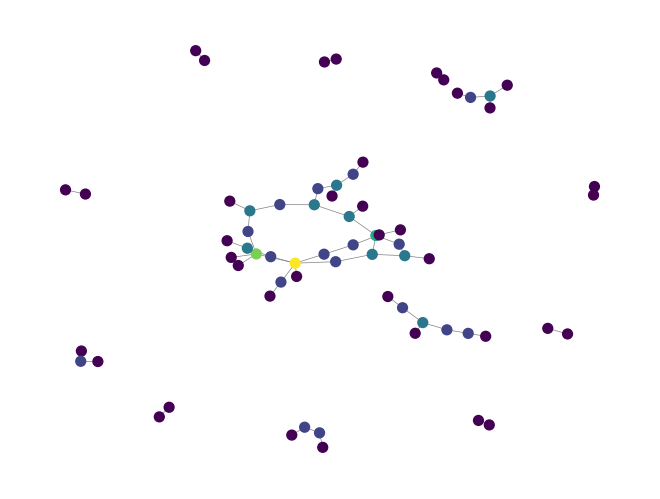

In [ ]:
n = 100
p = 0.01
(V,E) = ErdosRenyi(n,p)
deg = degree_centrality(V,E)
representacao_cor(V,E_aslist(V,E),deg,size = 50,labels=False)

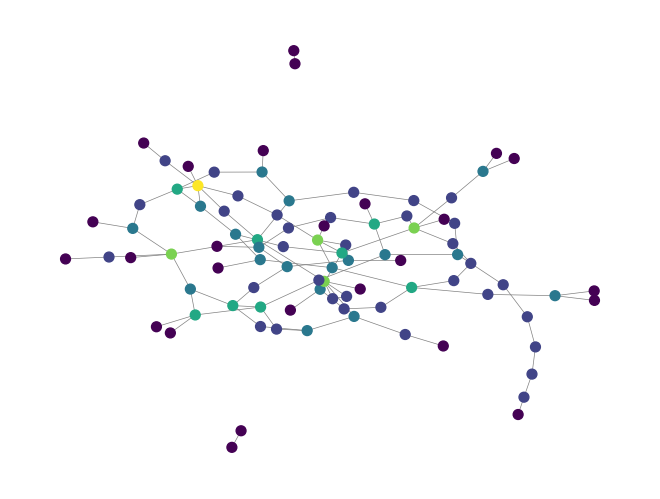

In [ ]:
n = 100
p = 0.02
(V,E) = ErdosRenyi(n,p)
deg = degree_centrality(V,E)
representacao_cor(V,E_aslist(V,E),deg,size = 50,labels=False)

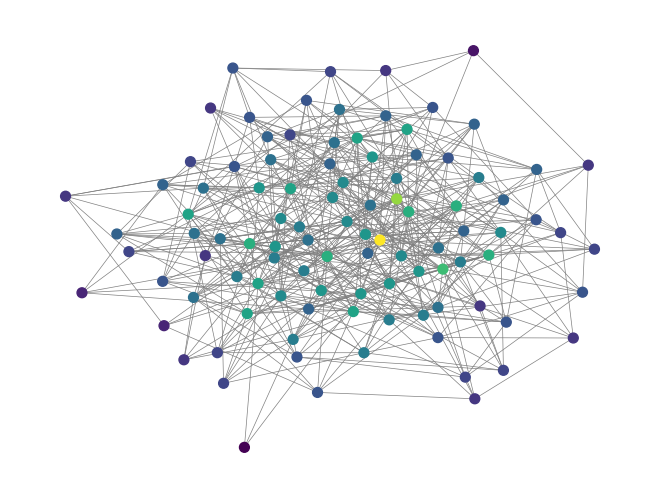

In [ ]:
n = 100
p = 0.1
(V,E) = ErdosRenyi(n,p)
deg = degree_centrality(V,E)
representacao_cor(V,E_aslist(V,E),deg,size = 50,labels=False)

O grau esperado para cada vértices é $(n-1)p$. Quanto maior o valor de $n$, é esperado que aconteça maior concentração dos graus ao redor do valor esperado.
No G(n,p), para qualquer $p$ constante maior do que zero, esta concentração ocorre a medida que $n$ cresce com alta probabilidade. Então a medida de centralidade por grau para $G(n,p)$ não tem muita relevância, pois todos os vértices tendem a ter aproximadamente a mesma centralidade.

Verificamos este fenômeno abaixo.

In [ ]:
import random as rd
def ErdosRenyi_grau(n,p):
    deg = {}
    for v in range(n):
        deg[v] = 0
    for v in range(n):
        for u in range(v+1,n):
            x = rd.random()
            if x<p:
                deg[v] += 1
                deg[u] += 1
    return deg

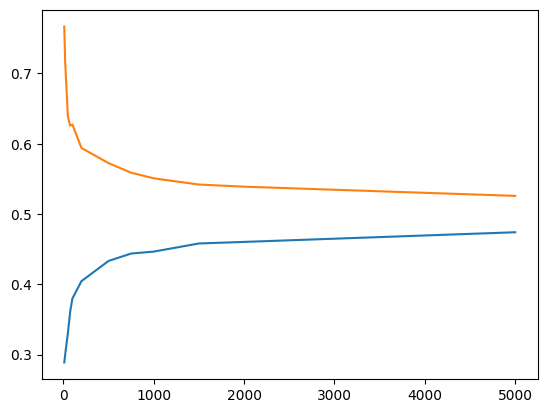

In [ ]:
t = 10
xs = [10,20,50,75,100,200,500,750,1000,1500,2000,5000]
y_min  = []
y_max = []
for n in xs:
    min_n = 0
    max_n = 0
    for i in range(t):
        p = 0.5
        V = range(n)
        deg = ErdosRenyi_grau(n,p)
        max_deg = 0
        min_deg = n-1
        for v in V:
            if deg[v]>max_deg:
                max_deg=deg[v]
            if deg[v]<min_deg:
                min_deg = deg[v]
        min_n += min_deg
        max_n += max_deg
    min_n /= (n-1)*t
    max_n /= (n-1)*t
    y_min.append(min_n)
    y_max.append(max_n)
plt.plot(xs,y_min)
plt.plot(xs,y_max)


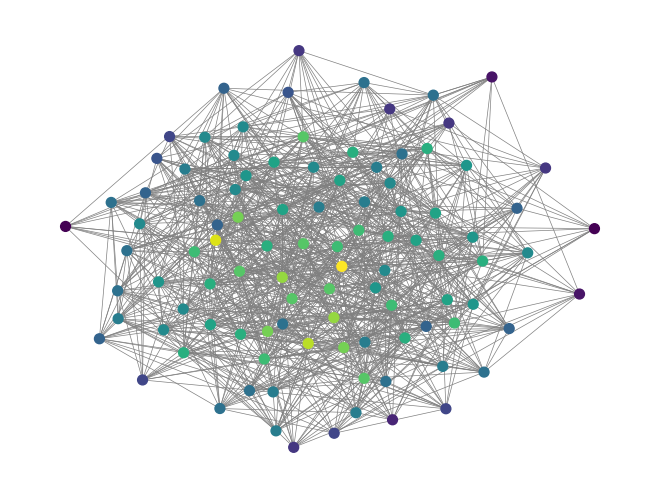

In [ ]:
n = 100
p = 0.2
(V,E) = ErdosRenyi(n,p)
deg = degree_centrality(V,E)
representacao_cor(V,E_aslist(V,E),deg,size = 50,labels=False)

### Centralidade de grau em grafos aleatórios geométricos

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


def rep_geom_cor(V, E, x, y, val):
    # Plot edges
    for v in V:
        for u in E[v]:
            plt.plot([x[v], x[u]], [y[v], y[u]], color="lightgrey", linewidth=0.5, zorder=1)

    # Plot nodes with heatmap-like coloring
    values = []
    xs = []
    ys = []
    for v in V:
        values.append(val[v])
        xs.append(x[v])
        ys.append(y[v])
    scatter = plt.scatter(xs, ys, c=values, cmap='viridis', zorder=2)  # Use 'val' for heatmap colors
    plt.axis("equal")
    plt.colorbar(scatter)
    plt.show()


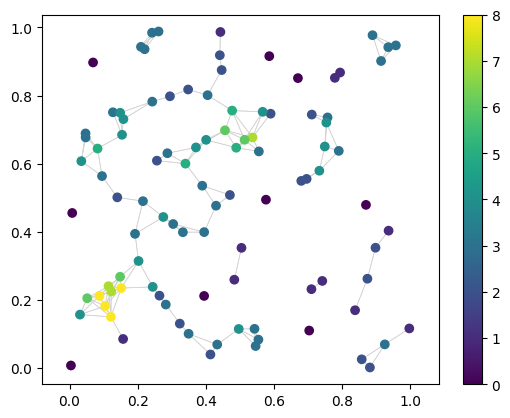

In [ ]:
V,E,x,y = Geom(100,0.1)
deg = degree_centrality(V,E)
rep_geom_cor(V,E,x,y,deg)

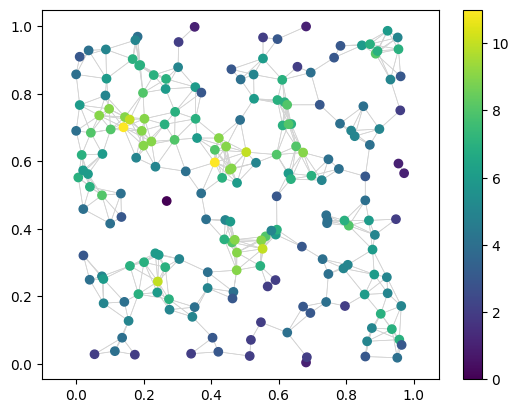

In [ ]:
V,E,x,y = Geom(200,0.1)
deg = degree_centrality(V,E)
rep_geom_cor(V,E,x,y,deg)

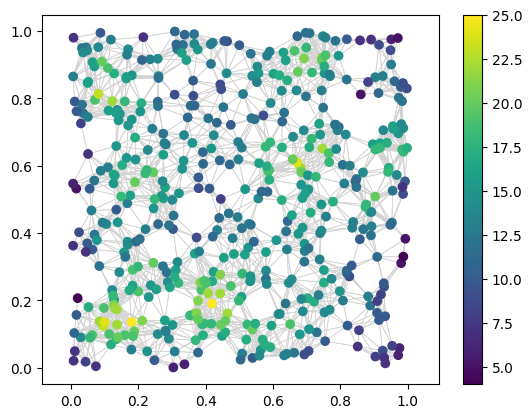

In [ ]:
V,E,x,y = Geom(500,0.1)
deg = degree_centrality(V,E)
rep_geom_cor(V,E,x,y,deg)

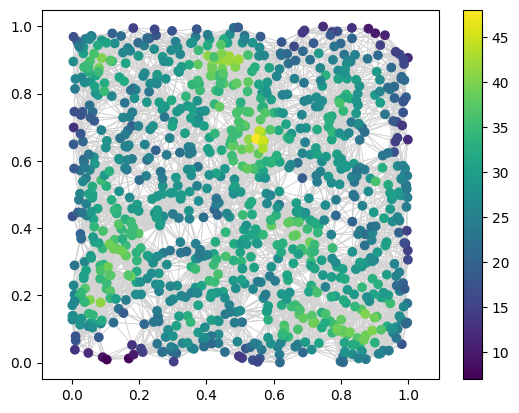

In [ ]:
V,E,x,y = Geom(1000,0.1)
deg = degree_centrality(V,E)
rep_geom_cor(V,E,x,y,deg)

Neste modelo de grafo aleatório geométrico, os vértices que são colocados perto das bordas do quadrado, tendem a possuir menos vizinhos. Isso se torna evidente na centralidade de grau, onde tais vértices possuem menor centralidade.

### Centralidade de grau em grafos aleatórios Watts-Strogatz

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import math
import numpy as np

def rep_WS_cor(V,E,val):
    n = len(V)
    angulo = 2*math.pi/n
    angulos = np.array(np.arange(0,2*math.pi, angulo))
    x = list(np.cos(angulos))
    y = list(np.sin(angulos))
    for v in V:
        for u in E[v]:
            plt.plot([x[v],x[u]],[y[v],y[u]],"gray",linewidth=0.5)
    values = []
    for v in V:
        values.append(val[v]/(n-1))
    scatter = plt.scatter(x, y, c=values, cmap='viridis', zorder=2)  # Use 'val' for heatmap colors
    plt.colorbar(scatter)
    plt.axis("equal")

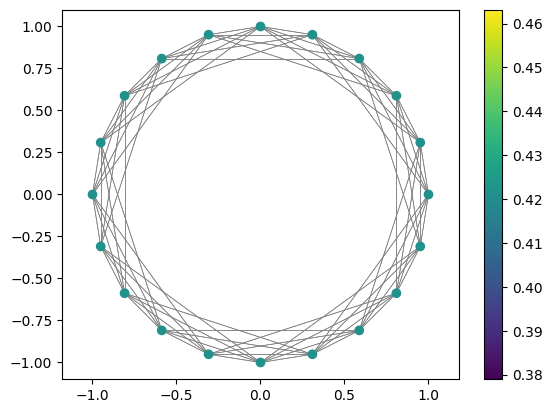

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0)
deg = degree_centrality(V,E)
rep_WS_cor(V,E,deg)

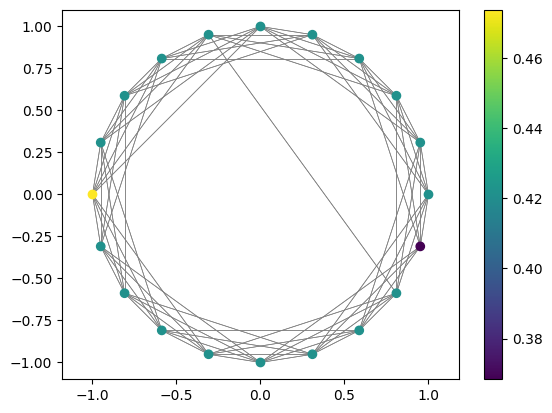

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.01)
deg = degree_centrality(V,E)
rep_WS_cor(V,E,deg)

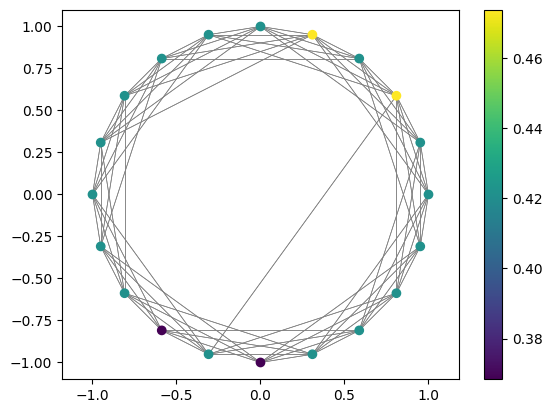

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.05)
deg = degree_centrality(V,E)
rep_WS_cor(V,E,deg)

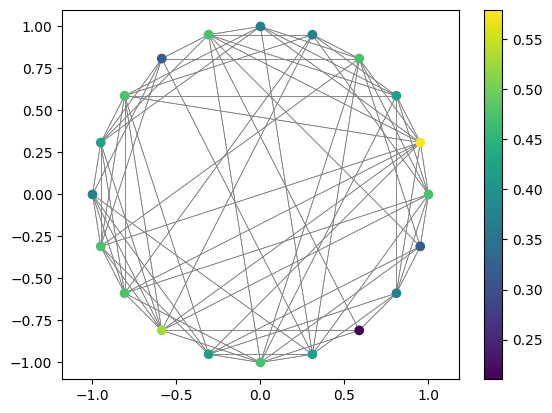

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.5)
deg = degree_centrality(V,E)
rep_WS_cor(V,E,deg)

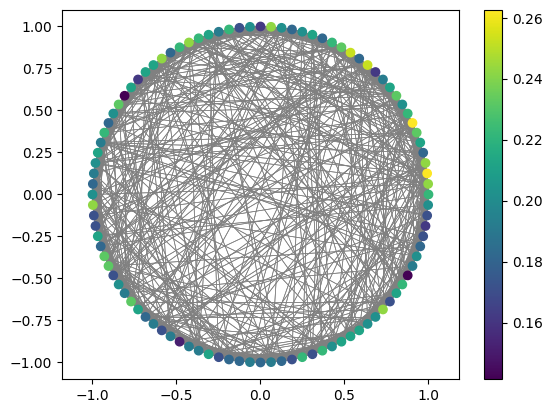

In [ ]:
n = 100
k = 20
V,E = WS(n,k, 0.5)
deg = degree_centrality(V,E)
rep_WS_cor(V,E,deg)

Quando a probabilidade de re-roteamento é pequena, o grafo é quase-regular e a centralidade de grau é parecidade para todos os vértices.

À medida que aumentamos a probabilidade de re-roteamento, aparece maior diversidade de graus. No entanto, quando essa probabilidade é muito grande o grafo passa a se parecer com o grafo de Erdős-Renyi.

## Proximidade/Closeness
Medida de centralidade que mensura o inverso das menores distâncias de um nó aos outros de um grafo. Nós com alta centralidade por proximidade possuem uma menor distância com relação a todos os outros nós do grafo analisado. Portanto, esses nós têm a capacidade de disseminar informações de maneira eficiente e rápida pelo grafo, tornando-os centrais na rede em termos de proximidade e acessibilidade aos demais nós.

$C_{C(i)} = \frac{N-1}{\sum_{i}^{n}d_{ij}}$

onde $d_{ij}$ é a menor distância entre os nós $i$ e $j$


In [ ]:
V = [1,2,3,4,5,6,7]
E = {1:[2,3,4],
     2:[1,5,4],
     3:[1,4],
     4:[1,2,3,5,6,7],
     5:[2,4,6],
     6:[4,5,7],
     7:[4,6]}

Para o cálculo das distâncias, utilizamos busca em largura.

In [ ]:
def bfs(id_adj_list, start_node, printMode=False):
    found = set([start_node]) #set de nós encontrados
    parent = []
    dist = {}
    dist[start_node] = 0
    queue = [start_node]
    while len(queue)>0:
        current_node = queue.pop(0)
        for neighbour in id_adj_list[current_node]:
            if neighbour not in found:
                found.add(neighbour)
                parent.append([current_node,neighbour])
                dist[neighbour] = dist[current_node]+1
                queue.append(neighbour)
                if printMode:
                    print(current_node,"->",neighbour)
    return parent,dist

In [ ]:
start_node = 1
parent,dist = bfs(E, start_node,printMode=True)
dist

1 -> 2
1 -> 3
1 -> 4
2 -> 5
4 -> 6
4 -> 7


{1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 2}

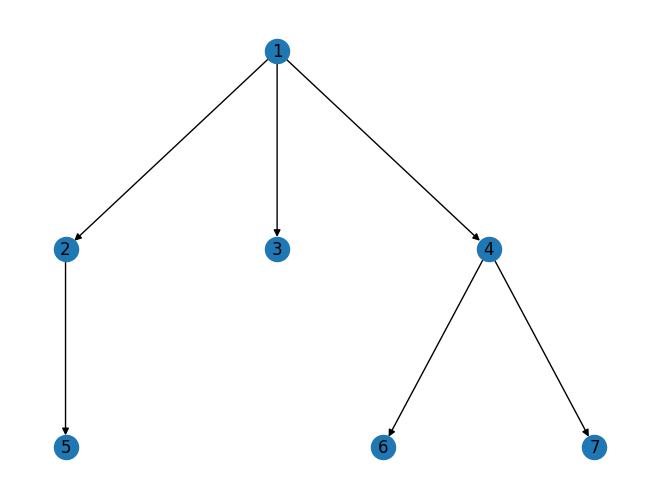

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout

T = nx.DiGraph()
T.add_edges_from(parent)

pos = graphviz_layout(T, prog="dot")
nx.draw(T, pos)
nx.draw_networkx_labels(T, pos)
plt.show()

In [ ]:
def closeness_centrality(V,E):
    C = {}
    for x in V:
        parent,dist = bfs(E, x)
        sum_dist = 0
        n = len(V)
        for v in dist:
            sum_dist += dist[v]
        if sum_dist==0:
            Cx = 0
        else:
            Cx = (n-1)/sum_dist
        C[x] = Cx
    return C

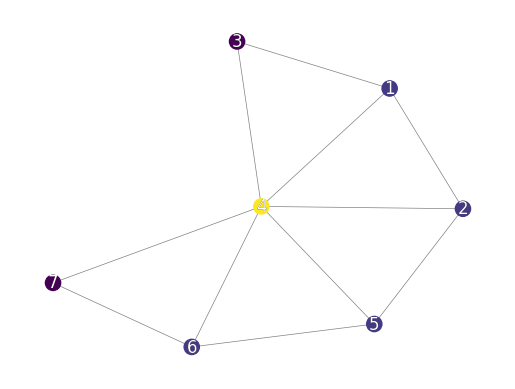

In [ ]:
C = closeness_centrality(V,E)
E_list = E_aslist(V,E)
representacao_cor(V,E_list,C)

### Closeness para grafos de Erdős-Renyi

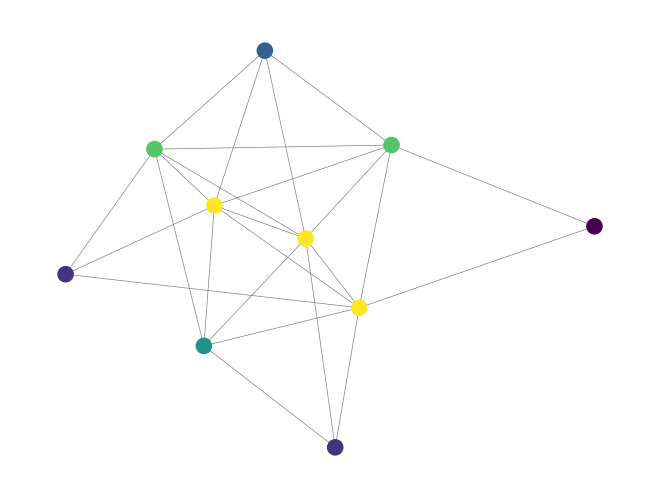

In [ ]:
(V,E) = ErdosRenyi(10,0.5)
C = closeness_centrality(V,E)
E_list = E_aslist(V,E)
representacao_cor(V,E_list,C,labels=False)

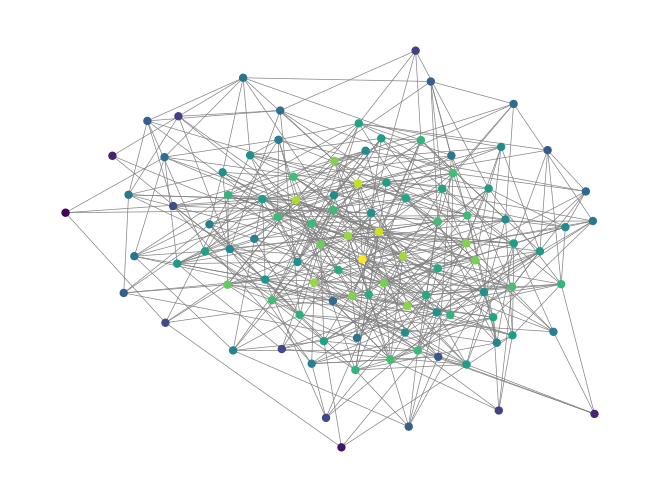

In [ ]:
(V,E) = ErdosRenyi(100,0.1)
C = closeness_centrality(V,E)
E_list = E_aslist(V,E)
representacao_cor(V,E_list,C,labels=False,size=25)

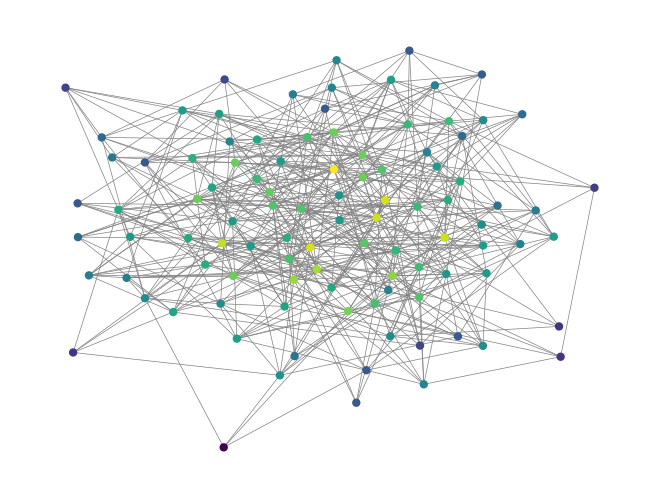

In [ ]:
(V,E) = ErdosRenyi(100,0.1)
C = closeness_centrality(V,E)
E_list = E_aslist(V,E)
representacao_cor(V,E_list,C,labels=False,size=25)

### Closeness para grafos aletórios geométricos

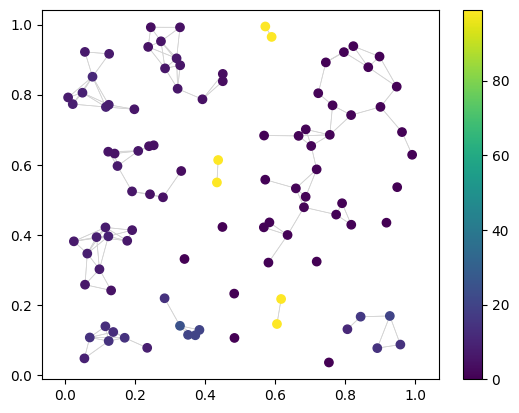

In [ ]:
V,E,x,y = Geom(100,0.1)
close = closeness_centrality(V,E)
rep_geom_cor(V,E,x,y,close)

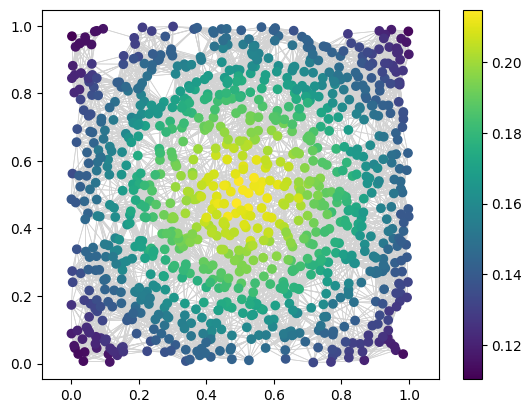

In [ ]:
V,E,x,y = Geom(1000,0.1)
close = closeness_centrality(V,E)
rep_geom_cor(V,E,x,y,close)

Note que o mesmo efeito de "borda" que ocorreu na centralidade de grau, volta a ocorrer e ainda mais nitidamente.

### Closeness para grafos aleatórios Watts-Strogatz

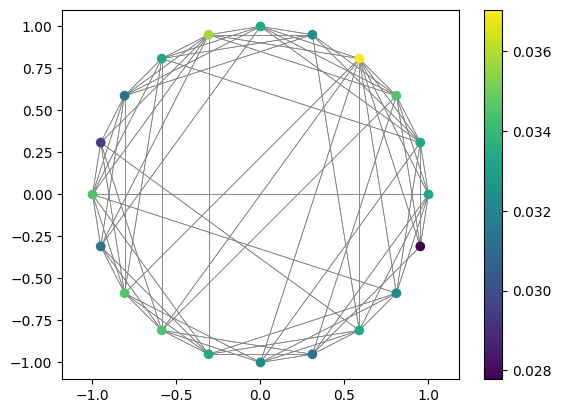

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.2)
close = closeness_centrality(V,E)
rep_WS_cor(V,E,close)

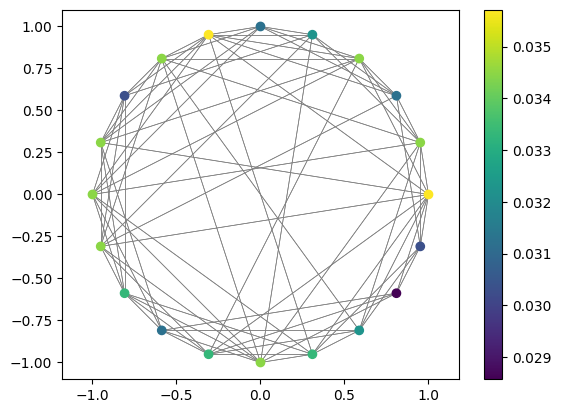

In [ ]:
n = 20
k = 8
V,E = WS(n,k, 0.5)
close = closeness_centrality(V,E)
rep_WS_cor(V,E,close)

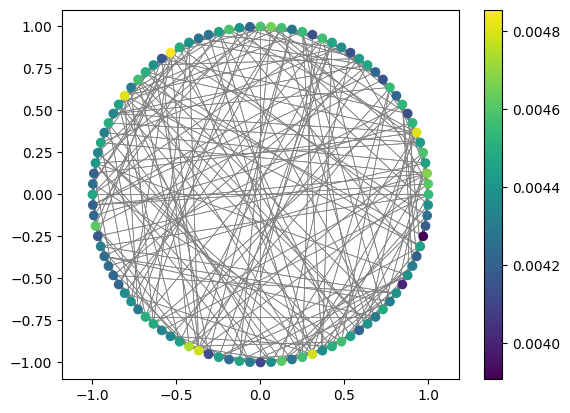

In [ ]:
n = 100
k = 10
V,E = WS(n,k, 0.5)
close = closeness_centrality(V,E)
rep_WS_cor(V,E,close)

## Centralidade Harmônica

É possível observar a grande similaridade entre as medidas de centralidade harmônica e por proximidade, e isso deve-se à ambas terem uma interpretação de importância baseada na proximidade de um nó aos outros de uma rede, porém, enquanto a centralidade por proximidade se concentra na distância média de um nó para todos os outros, a centralidade harmônica leva em conta a soma das inversas das distâncias, destacando nós que estão próximos de muitos outros na rede.


$C_{H(j)}= \sum_{i=1}^{n} (1/d_{ij})​$

A centralidade harmônica se mostrou similar a de proximidade em nossos experimentos.

In [ ]:
def  harmonic_centrality(V,E):
    C = {}
    for x in V:
        parent,dist = bfs(E, x)
        Cx = 0
        n = len(V)
        for v in dist:
            if dist[v]!=0:
                Cx += 1/dist[v]
        C[x] = Cx
    return C

### Centralidade harmônica para grafos de Erdős-Renyi

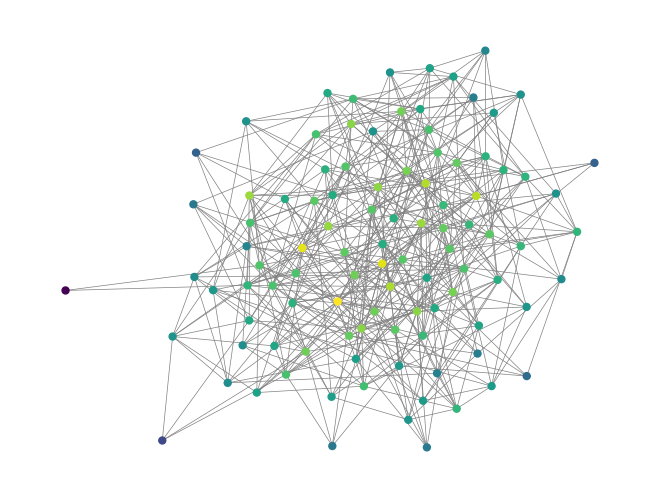

In [ ]:
(V,E) = ErdosRenyi(100,0.1)
C = harmonic_centrality(V,E)
E_list = E_aslist(V,E)
representacao_cor(V,E_list,C,labels=False,size=25)

### Centralidade harmônica para grafos geométricos

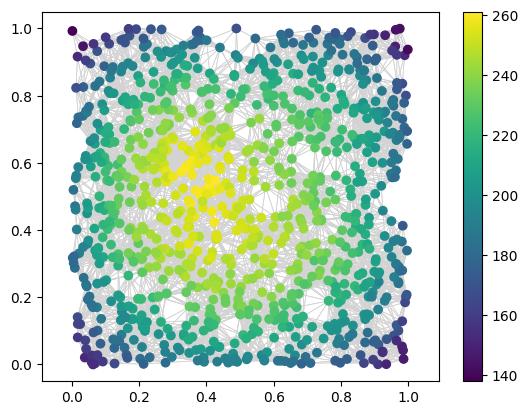

In [ ]:
V,E,x,y = Geom(1000,0.1)
close = harmonic_centrality(V,E)
rep_geom_cor(V,E,x,y,close)

### Centralidade harmônica para grafos aleatórios Watts-Strogatz

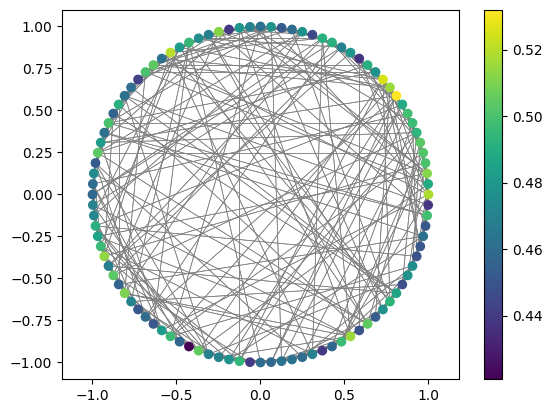

In [ ]:
n = 100
k = 10
V,E = WS(n,k, 0.5)
close = harmonic_centrality(V,E)
rep_WS_cor(V,E,close)

# Page Rank

O PageRank é uma medida de centralidade baseado em autovalores. Foi utilizada inicialmente pelo Google para a classificação de resultados de pesquisa. Vamos trabalhar com o grafo a seguir:

In [ ]:
V = [1,2,3,4,5,6,7]
E = {1:[2,3,4],
     2:[1,5,4],
     3:[1,4],
     4:[1,2,3,5,6,7],
     5:[2,4,6],
     6:[4,5,7],
     7:[4,6]}

Para esta medida, é mais simples trabalhar com a representação de matriz de adjacência:

In [ ]:
def printMatriz(A):
    for r in A:
        for entry in r:
            print('%.3f' %entry,end=" ")
        print()

In [ ]:
n = len(V)
A = [[0]*n for i in range(n)]
for v in range(n):
    for u in E[v+1]:
        A[v][u-1] = 1
for r in A:
    print(r)

[0, 1, 1, 1, 0, 0, 0]
[1, 0, 0, 1, 1, 0, 0]
[1, 0, 0, 1, 0, 0, 0]
[1, 1, 1, 0, 1, 1, 1]
[0, 1, 0, 1, 0, 1, 0]
[0, 0, 0, 1, 1, 0, 1]
[0, 0, 0, 1, 0, 1, 0]


Calculamos uma matriz $B$ a partir da matriz de adjacência $A$, dividindo cada coluna pelo número de vizinhos do vértice daquela coluna. Assim, cada coluna tem soma $1$:

In [ ]:
def LinkAdj(A):
    n = len(A[0])
    B = [[0]*n for x in [0]*n]
    vizinhos = [0]*n
    for col in range(n):
        for linha in range(n):
            vizinhos[col] += A[linha][col]
    for col in range(n):
        for linha in range(n):
            if vizinhos[col]==0:
                vizinhos[col] = 1
            B[linha][col] = A[linha][col]/vizinhos[col]
    return B

In [ ]:
B = LinkAdj(A)
printMatriz(B)

0.000 0.333 0.500 0.167 0.000 0.000 0.000 
0.333 0.000 0.000 0.167 0.333 0.000 0.000 
0.333 0.000 0.000 0.167 0.000 0.000 0.000 
0.333 0.333 0.500 0.000 0.333 0.333 0.500 
0.000 0.333 0.000 0.167 0.000 0.333 0.000 
0.000 0.000 0.000 0.167 0.333 0.000 0.500 
0.000 0.000 0.000 0.167 0.000 0.333 0.000 


Assim, cada coluna representa uma distribuição de probabilidade partindo de um vértice $v$ e seguindo cada link com a probabilidade na matriz $B$. No entanto, também é colocada a probabilidade de "pular" de $v$ para qualquer outro vértice.Isso ocorre com probabilidade $1-\alpha$, onde $\alpha$ é um parâmetro do modelo.

In [ ]:
alpha = 0.9
n = len(B[0])
J =  [[1/n]*n for x in [0]*n]
L = alpha*np.array(B) + (1-alpha)*np.array(J)
printMatriz(L)

0.014 0.314 0.464 0.164 0.014 0.014 0.014 
0.314 0.014 0.014 0.164 0.314 0.014 0.014 
0.314 0.014 0.014 0.164 0.014 0.014 0.014 
0.314 0.314 0.464 0.014 0.314 0.314 0.464 
0.014 0.314 0.014 0.164 0.014 0.314 0.014 
0.014 0.014 0.014 0.164 0.314 0.014 0.464 
0.014 0.014 0.014 0.164 0.014 0.314 0.014 


A centralidade é dada por um auto-vetor para o auto-valor $1$. Abaixo, usamos o método de potências para estimar esse auto-vetor.

In [ ]:
x = np.array([1/n]*n)
print(x)
for i in range(100):
    x = np.matmul(L,x)
    x = x/x.sum()
print(x)

[0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
[0.13733993 0.13577332 0.09504132 0.26369085 0.13577332 0.13733993
 0.09504132]


Assim, obtemos o seguinte código:

In [ ]:
def pagerank(A,alpha,it):
    B = LinkAdj(A)
    n = len(B[0])
    J =  [[1/n]*n for x in [0]*n]
    L = alpha*np.array(B) + (1-alpha)*np.array(J)
    x = np.array([1/n]*n)
    for i in range(it):
        x = np.matmul(L,x)
        x = x/x.sum()
    pr = {}
    for i in range(n):
        pr[i] = x[i]
    return pr

In [ ]:
def AdjMatrix(Elist):
    n = len(Elist)
    A = [[0]*n for x in range(n)]
    for v in Elist:
        for u in Elist[v]:
            A[u][v]=1
    return A

### Page rank para grafos aleatórios

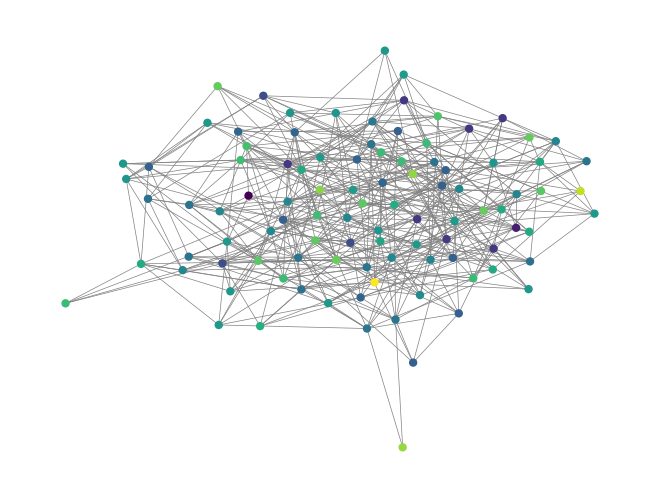

In [ ]:
V,E = ErdosRenyi(100,0.1)
A = AdjMatrix(E)
pr = pagerank(A,0.9,1000)
representacao_cor(V,E_list,pr,labels=False,size=25)

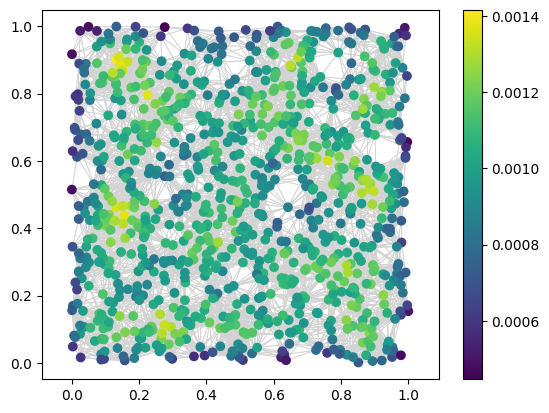

In [ ]:
V,E,x,y = Geom(1000,0.1)
A = AdjMatrix(E)
pr = pagerank(A,0.9,1000)
rep_geom_cor(V,E,x,y,pr)

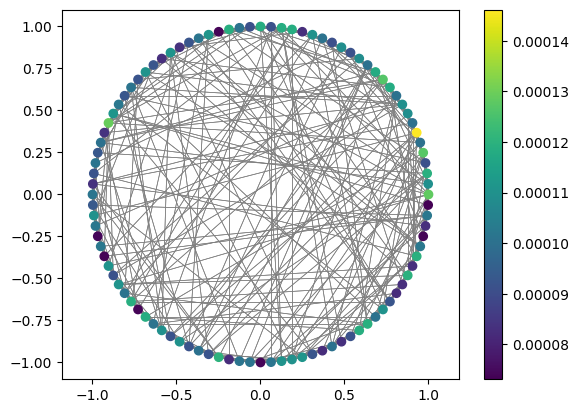

In [ ]:
n = 100
k = 10
V,E = WS(n,k, 0.5)
A = AdjMatrix(E)
pr = pagerank(A,0.9,1000)
rep_WS_cor(V,E,pr)

# Estudo de caso: Aeroportos

Aplicamos as medidas de centralidade em dados reais de aeroportos. As planilhas a seguir contêm dados de vôos.

In [ ]:
import pandas as pd
link = "https://drive.google.com/uc?export=download&id=1wFp9e0N4kF5AplBtKJJtIemthUfc2xhZ"
link_geo = "https://drive.google.com/uc?export=download&id=1-6rBHgXkNuyVpUzw987Ff3Uv3SA_Z5VY"
df = pd.read_csv(link)
df

,source,dest
0,AER,KZN
1,ASF,KZN
2,ASF,MRV
3,CEK,KZN
4,CEK,OVB
...,...,...
37590,TSV,WIN
37591,WGA,MEL
37592,WIN,LRE
37593,WIN,TSV


In [ ]:
df_air = pd.read_csv(link_geo)
df_air

,Unnamed: 0,iata_code,name,gps_code,latitude_deg,longitude_deg,iso_country
0,240,UTK,Utirik Airport,03N,11.222219,169.851429,MH
1,476,OCA,Ocean Reef Club Airport,07FA,25.325399,-80.274803,US
2,511,CUX,Cuddihy Field,07TE,27.721100,-97.512802,US
3,725,CSE,Crested Butte Airpark,0CO2,38.851918,-106.928341,US
4,1029,CUS,Columbus Airport,0NM0,31.823898,-107.629924,US
...,...,...,...,...,...,...,...
9092,80704,DLC,Dalian Zhoushuizi International Airport,ZYTL,38.965698,121.539001,CN
9093,80705,TNH,Tonghua Sanyuanpu Airport,ZYTN,42.253889,125.703333,CN
9094,80706,SHE,Shenyang Taoxian International Airport,ZYTX,41.639801,123.483002,CN
9095,80708,YNJ,Yanji Chaoyangchuan Airport,ZYYJ,42.882801,129.451004,CN


Cruzamento de dados:

In [ ]:
country = {}
air_country={}
for index,row in df_air.iterrows():
    code = row["iata_code"]
    c = row["iso_country"]
    country[code] = c
    if c in air_country:
        air_country[c].append(code)
    else:
        air_country[c] = [code]

Como há muitos dados, trabalhamos com os dados por país:

In [ ]:
def country(c):
    V_names = []
    for index,row in df.iterrows():
        source = row["source"]
        dest = row["dest"]
        if source in air_country[c] and dest in air_country[c]:
            if source not in V_names:
                V_names.append(source)
            if dest not in V_names:
                V_names.append(dest)
    id={}
    sigla={}
    i=0
    for v in V_names:
        id[v]=i
        sigla[i]=v
        i += 1
    V = list(range(i))
    E = {}
    for index,row in df.iterrows():
        source_name = row["source"]
        dest_name = row["dest"]
        if source_name in V_names and dest_name in V_names:
            source = id[row["source"]]
            dest = id[row["dest"]]
            if source != dest:
                if source in E:
                    E[source].append(dest)
                else:
                    E[source] = [dest]
                if dest in E:
                    E[dest].append(source)
                else:
                    E[dest] = [source]
    Elist = E_aslist(V,E)
    return V_names, V, id, sigla, Elist, E

Brasil

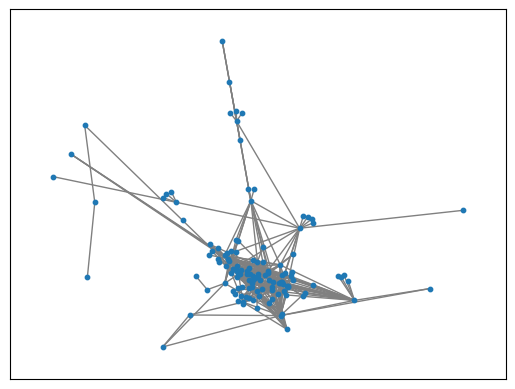

In [ ]:
V_names, V, id, sigla, Elist, E = country("BR")
representacao(V,Elist,size=10,labels=False,layout="spring")

Veja que esta visualização não é muito útil.

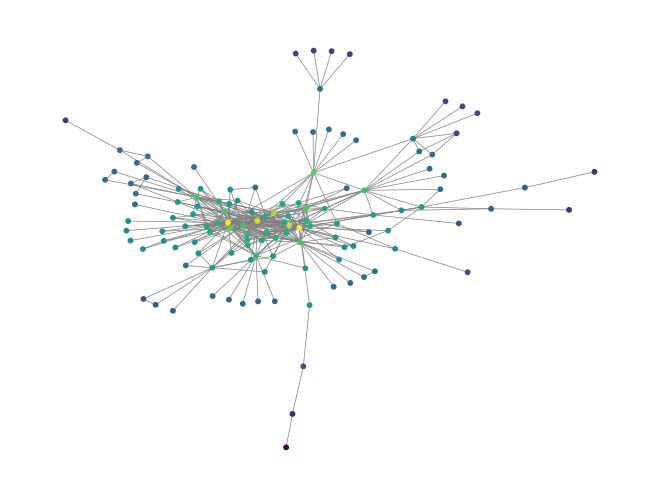

In [ ]:
close = closeness_centrality(V,E)
representacao_cor(V,Elist,close,size = 10,labels=False)

## Utilizando dados geográficos

Para criar uma visualização mais interessante, utilizamos dados de latitude e longitude.


In [ ]:
def geo(c):
    df_geo = df_air.query('iso_country=="'+c+'"')
    latitude = {}
    longitude = {}
    for index,row in df_geo.iterrows():
        iata = row["iata_code"]
        if iata in V_names:
            latitude[id[iata]] = row["latitude_deg"]
            longitude[id[iata]] = row["longitude_deg"]
    return latitude, longitude

In [ ]:
V_names, V, id, sigla, Elist, E = country("BR")
latitude, longitude = geo("BR")

Veja a diferença na representação:

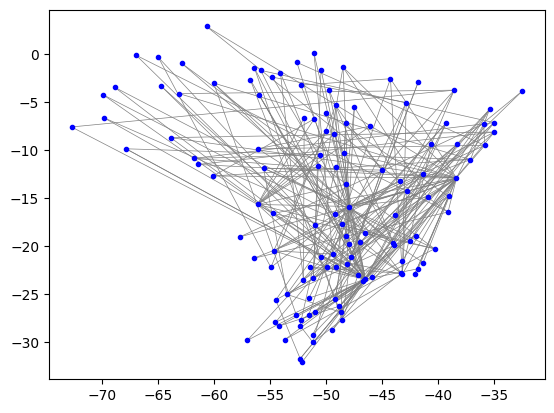

In [ ]:
rep_geom(V,Elist,longitude,latitude)

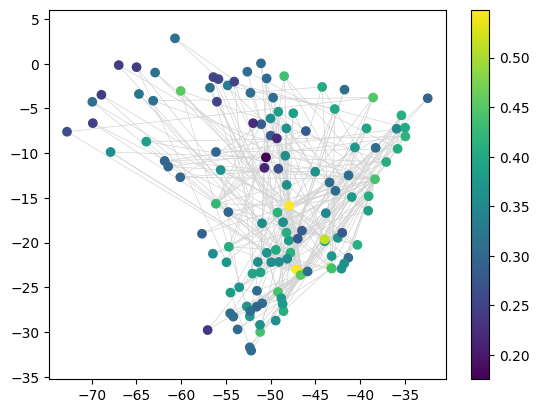

In [ ]:
close = closeness_centrality(V,E)
rep_geom_cor(V,Elist,longitude,latitude,close)

Canadá

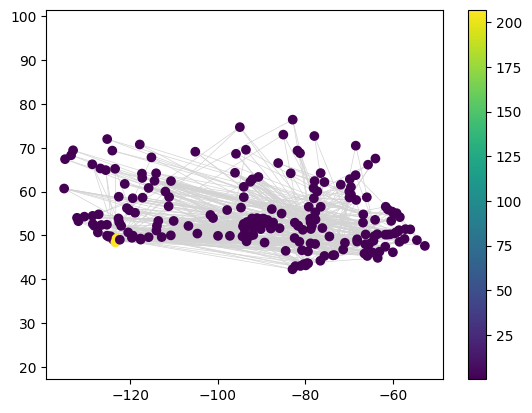

In [ ]:
V_names, V, id, sigla, Elist, E = country("CA")
latitude, longitude = geo("CA")
close = closeness_centrality(V,E)
rep_geom_cor(V,Elist,longitude,latitude,close)

Austrália

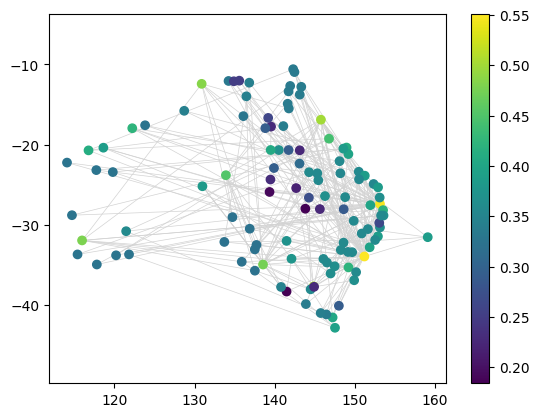

In [ ]:
V_names, V, id, sigla, Elist, E = country("AU")
latitude, longitude = geo("AU")
close = closeness_centrality(V,E)
rep_geom_cor(V,Elist,longitude,latitude,close)

França

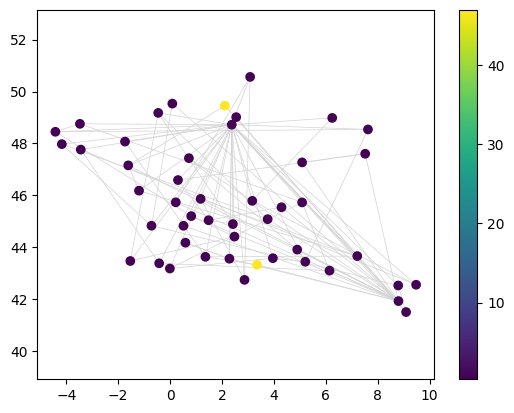

In [ ]:
V_names, V, id, sigla, Elist, E = country("FR")
latitude, longitude = geo("FR")
close = closeness_centrality(V,E)
rep_geom_cor(V,Elist,longitude,latitude,close)